In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [7]:
Xtr[:5]

tensor([[ 0,  0,  0],
        [ 0,  0, 25],
        [ 0, 25, 21],
        [25, 21,  8],
        [21,  8,  5]])

In [19]:
n_embd = 10 # embedding dimension
n_hidden = 200 # hidden dimension

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g)*(5/3)/((block_size*n_embd)**0.5) # Kaiming init
# b1 = torch.randn(n_hidden, generator=g)*0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g)*0.01
b2 = torch.randn(vocab_size, generator=g)*0.01

bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden)) 
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]

print(sum(p.nelement() for p in parameters)) # number of total parameters
for p in parameters:
    p.requires_grad = True

12097


In [12]:
Xtr[:1]

tensor([[0, 0, 0]])

In [8]:
C[Xtr[:1]]

tensor([[[ 1.5674, -0.2373, -0.0274, -1.1008,  0.2859, -0.0296, -1.5471,
           0.6049,  0.0791,  0.9046],
         [ 1.5674, -0.2373, -0.0274, -1.1008,  0.2859, -0.0296, -1.5471,
           0.6049,  0.0791,  0.9046],
         [ 1.5674, -0.2373, -0.0274, -1.1008,  0.2859, -0.0296, -1.5471,
           0.6049,  0.0791,  0.9046]]], grad_fn=<IndexBackward0>)

In [15]:
C[[0,0,0]]

tensor([[ 1.5674, -0.2373, -0.0274, -1.1008,  0.2859, -0.0296, -1.5471,  0.6049,
          0.0791,  0.9046],
        [ 1.5674, -0.2373, -0.0274, -1.1008,  0.2859, -0.0296, -1.5471,  0.6049,
          0.0791,  0.9046],
        [ 1.5674, -0.2373, -0.0274, -1.1008,  0.2859, -0.0296, -1.5471,  0.6049,
          0.0791,  0.9046]], grad_fn=<IndexBackward0>)

- `Xtr[:1] = [[0,0,0]]` 
- `C[0] = [ 1.5674, -0.2373, -0.0274, -1.1008,  0.2859, -0.0296, -1.5471,0.6049,  0.0791,  0.9046]`
- So `C[Xtr[:1]] = C[[[0,0,0]]]`


In [9]:
Xtr[:1].shape, C[Xtr[:1]].shape

(torch.Size([1, 3]), torch.Size([1, 3, 10]))

In [20]:
max_steps = 200000
batch_size = 32
lossi = []

# Training loop
for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g) # random indices
    Xb, Yb = Xtr[ix], Ytr[ix] # Xb.shape = (batch_size, block_size), Yb.shape = (batch_size,)

    # Forward pass
    emb = C[Xb] # emb.shape = (batch_size,block_size,n_embd)
    embcat = emb.view(emb.shape[0], -1) # embcat.shape = (batch_size,block_size*n_embd)
    # Linear layer
    hpreact = embcat @ W1 # Hidden layer pre activation
    # BatchNorm Layer
    # --------------------------------------------------------------------
    bnmeani = hpreact.mean(0,keepdim=True)
    bnstdi = hpreact.std(0,keepdim=True)
    hpreact = bngain*(hpreact - bnmeani)/bnstdi + bnbias # Batch Normalization
    with torch.no_grad():
        bnmean_running = 0.999*bnmean_running + 0.001*bnmeani
        bnstd_running = 0.999*bnstd_running + 0.001*bnstdi 
    # --------------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # Using activation on hidden layer
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)
    # print(i, loss.item())

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update weights
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data -= p.grad * lr

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

# print(f'Training Loss: {loss.item()}')

      0/ 200000: 3.3233
  10000/ 200000: 2.0321
  20000/ 200000: 2.5677
  30000/ 200000: 2.0131
  40000/ 200000: 2.2446
  50000/ 200000: 1.8895
  60000/ 200000: 2.0786
  70000/ 200000: 2.3688
  80000/ 200000: 2.2917
  90000/ 200000: 2.0242
 100000/ 200000: 2.3678
 110000/ 200000: 2.3134
 120000/ 200000: 1.6414
 130000/ 200000: 1.9306
 140000/ 200000: 2.2232
 150000/ 200000: 2.0025
 160000/ 200000: 2.0989
 170000/ 200000: 2.4944
 180000/ 200000: 2.0206
 190000/ 200000: 2.1705


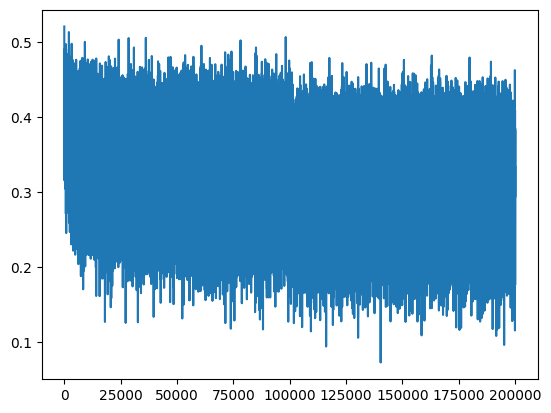

In [7]:
plt.plot(lossi);

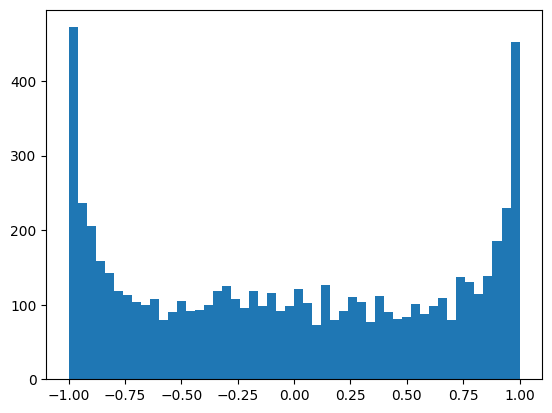

In [21]:
plt.hist(h.view(-1).detach().numpy(), bins=50);

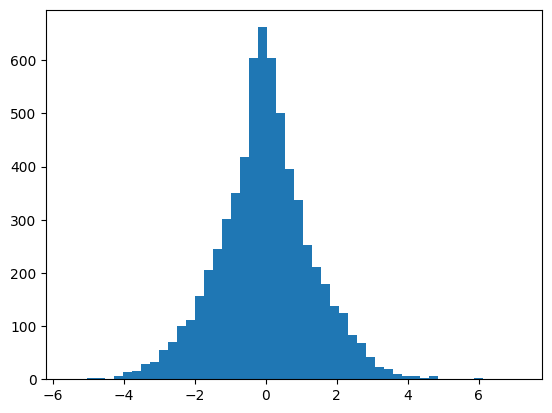

In [22]:
plt.hist(hpreact.view(-1).tolist(), bins=50);

- This looks almost like a normal distribution if all the techniques are applied correctly.

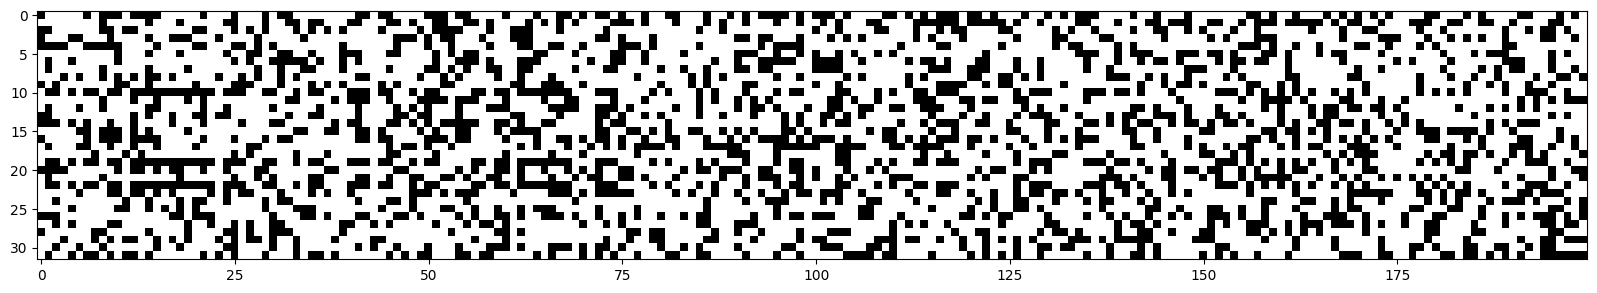

In [25]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap='gray',interpolation='nearest');

- The formula for the hyperbolic tangent is:

$$\tanh(x) = \frac{\sinh(x)}{\cosh(x)} = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$
- X axis contains the neurons' index. If the whole column is white, it means that the neuron is not activated by any input. By looking at the image, we can see that many neurons are activated by only a few inputs.
- `tanh` saturation can be avoided if hpreact has low values. That's why we need to multiply small factors with `W1`

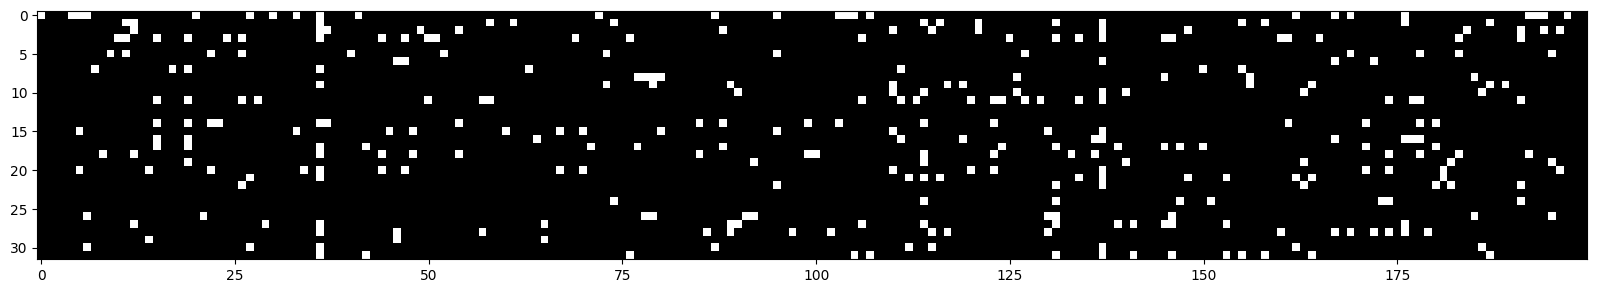

In [23]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap='gray',interpolation='nearest');

- After reducing the values of W1, we can see that the neurons are activated by more inputs. This is because the neurons are not saturated anymore.

tensor(-0.0004) tensor(0.9922)
tensor(-0.0009) tensor(1.0358)


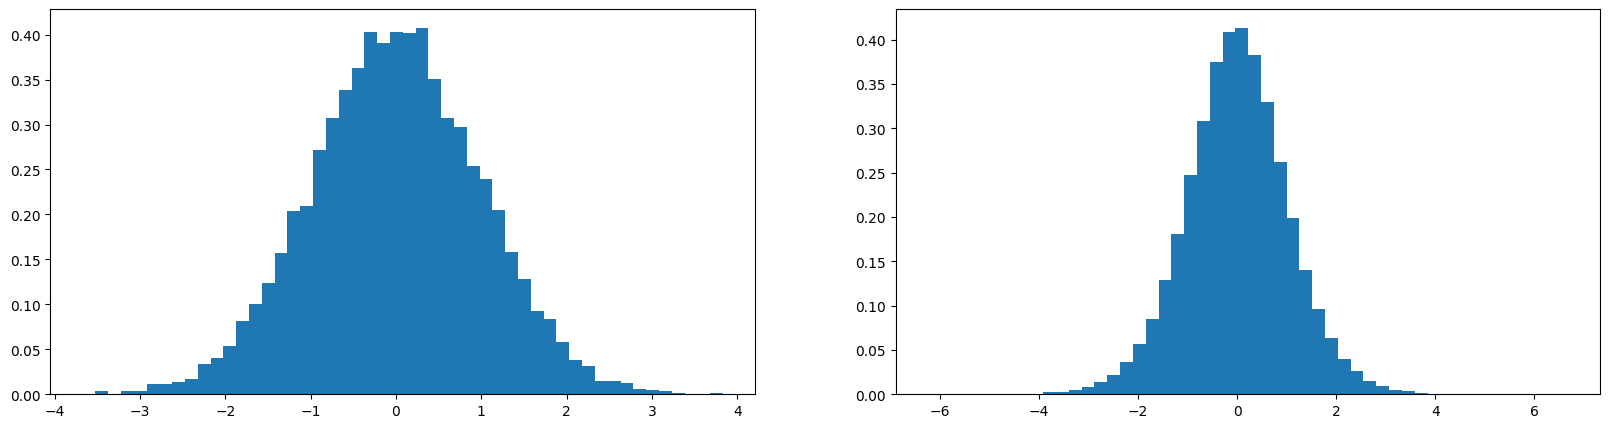

In [ ]:
x = torch.randn(1000,10) # size (1000,10)
w = torch.randn(10,200)/10**0.5 # size (10,200)
# Dividing by sqrt of first dimension often does the job of keeping the s.d of y as 1
y = x @ w # size (1000,200)
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(),50,density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50,density=True);

- `torch.randn` outputs random values from a normal distribution with a mean of 0 and a standard deviation of 1.
- We have to multiply the weight with a small number such that the standard deviation of the matrix multiplication is 1 i.e in this case, `y` has a standard deviation of 1.
- Refer to [this](https://pytorch.org/docs/stable/nn.init.html) to learn about Kaiming initialization.

In [24]:
# Code for Inference
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0674033164978027
val 2.1056692600250244


- Refer to [Resnet](https://github.com/pytorch/vision/blob/main/torchvision/models/resnet.py) to learn about the implementation of Resnet in Pytorch which uses BatchNorm Layers.

In [73]:
# The classes we create here are the same API as nn.Module in PyTorch
class Linear:
    def __init__(self,fan_in,fan_out,bias=True):
        self.weight = torch.randn((fan_in,fan_out),generator=g)/fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self,x):
        if self.bias is None:
            self.out = x @ self.weight
        else:
            self.out = x @ self.weight + self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1D:
    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self,x):
        # Calculate the Forward pass
        if self.training:
            xmean = x.mean(0,keepdim=True) # batch mean
            xvar = x.var(0,keepdim=True) # batch var
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / (xvar + self.eps).sqrt() # normalize
        self.out = self.gamma * xhat + self.beta # scale and shift
        # update running mean and var
        if self.training:
            self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*xmean
            self.running_var = (1-self.momentum)*self.running_var + self.momentum*xvar

        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self,x):
        self.out = x.tanh()
        return self.out
    
    def parameters(self):
        return []
    
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(block_size*n_embd, n_hidden,bias=False),BatchNorm1D(n_hidden),Tanh(),
    Linear(         n_hidden,n_hidden, bias=False),BatchNorm1D(n_hidden),Tanh(),
    Linear(         n_hidden,n_hidden, bias=False),BatchNorm1D(n_hidden),Tanh(),
    Linear(         n_hidden,n_hidden, bias=False),BatchNorm1D(n_hidden),Tanh(),
    Linear(         n_hidden,n_hidden, bias=False),BatchNorm1D(n_hidden),Tanh(),
    Linear(         n_hidden,vocab_size,bias=False),BatchNorm1D(vocab_size)    
]

# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

with torch.no_grad():
    layers[-1].gamma *= 0.1
    # layers[-1].weight *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weight *= 5/3
    
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of total parameters
for p in parameters:
    p.requires_grad = True

47024


In [74]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.2870


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.62%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.47%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.16%
layer 11 (      Tanh): mean +0.00, std 0.65, saturated: 1.81%
layer 14 (      Tanh): mean -0.00, std 0.65, saturated: 1.78%


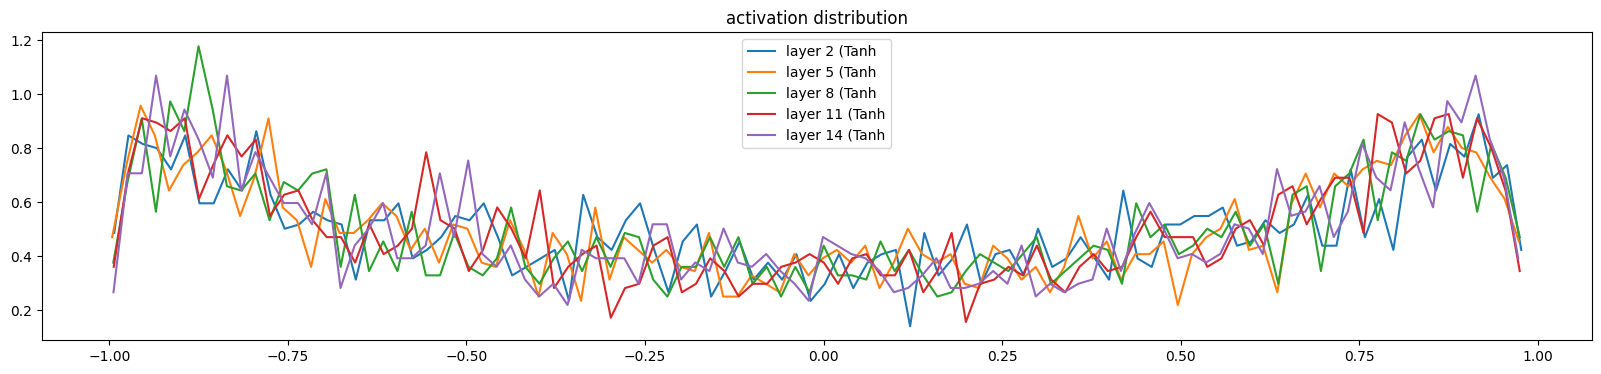

In [75]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution');

layer 2 (      Tanh): mean +0.000000, std 3.682950e-03
layer 5 (      Tanh): mean -0.000000, std 3.262606e-03
layer 8 (      Tanh): mean +0.000000, std 2.973727e-03
layer 11 (      Tanh): mean -0.000000, std 2.741108e-03
layer 14 (      Tanh): mean -0.000000, std 2.584293e-03


Text(0.5, 1.0, 'gradient distribution')

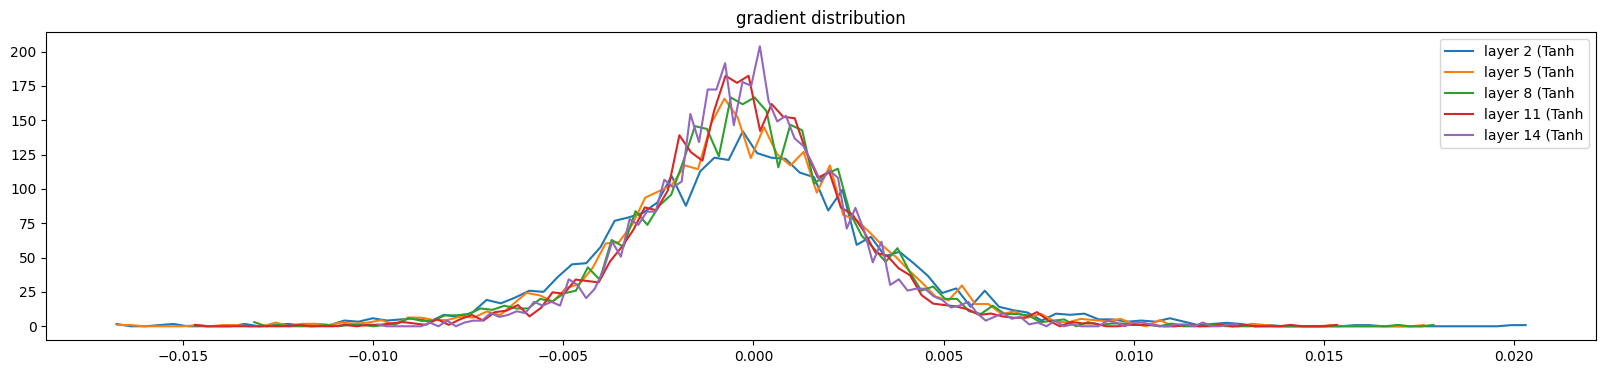

In [76]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

- This plot represents gradient distribution of the tanh layers. They are almost similar across all the tanh layers. The reason is that we multiplied 5/3 as the gain. Which nulifies the squashing effect of tanh.

- If we use gain < 5/3, the continuous squashing decreases saturation of the later layers, which causes the plot for the later layers to be more spread out.(Cz then their gradients have less posssibility of being zero)

- If we use gain > 5/3, the gain dominates the squashing effect of tanh, which causes the plot for the later layers to be more concentrated.(Cz then their gradients have more posssibility of being zero)

weight   (27, 10) | mean +0.000980 | std 1.189170e-02 | grad:data ratio 1.189149e-02
weight  (30, 100) | mean +0.000118 | std 1.005290e-02 | grad:data ratio 3.214555e-02
weight (100, 100) | mean +0.000033 | std 7.821211e-03 | grad:data ratio 4.653361e-02
weight (100, 100) | mean -0.000107 | std 6.655620e-03 | grad:data ratio 3.925851e-02
weight (100, 100) | mean -0.000017 | std 6.086040e-03 | grad:data ratio 3.605767e-02
weight (100, 100) | mean -0.000077 | std 5.075620e-03 | grad:data ratio 3.015269e-02
weight  (100, 27) | mean -0.000000 | std 2.056585e-02 | grad:data ratio 2.909911e-01


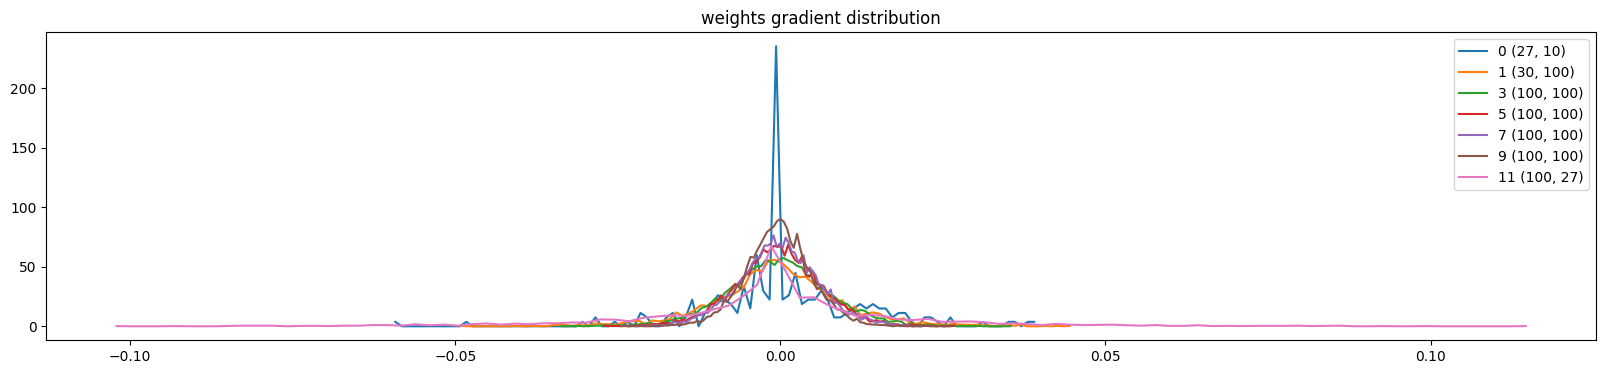

In [63]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

- Here we can see that the last layer is more spread out than the other ones. And from its standard deviation, we can see that it trains almost 10 times faster than the other layers(i.e its gradient is 10 times larger than the other layers).

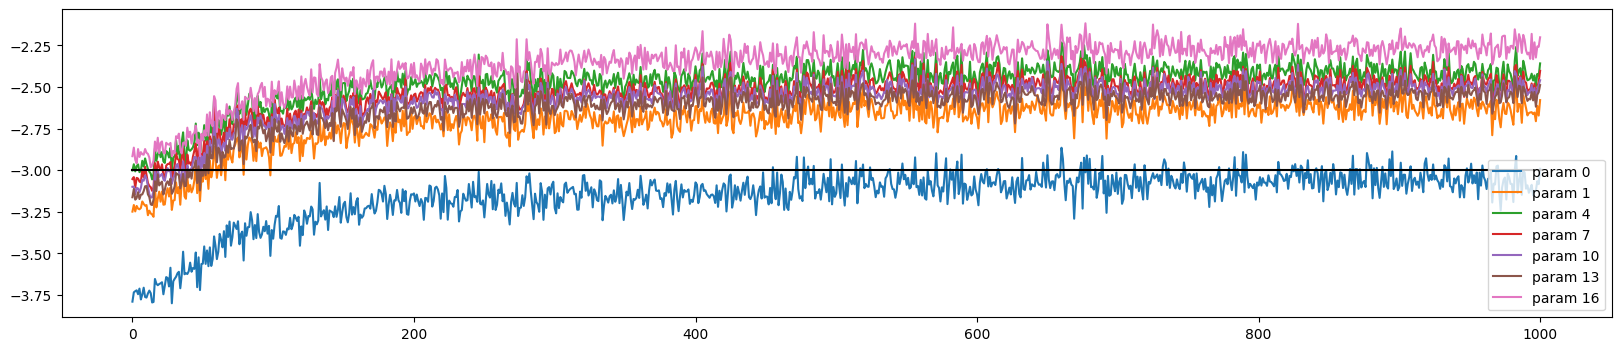

In [77]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

- Here the last layer is an outlier cz we forced it to be less confident. Almost all of the layers train much faster as we can see from this plot

- If the graph for a layer is below the -3 line, it means that the layer is learing too slow. -3 line is a decent threshold for the learning rate.

- When we use batchnorm layers, we have freedom to not use kaiming init or gain and it won't affect forward and backward pass. But it does only affect the update diagram. So we just have to adjust the learning rate.